# Glass Identification — Random Forest Classification

**Dataset:** Glass Identification Dataset (`glass.xlsx`)
**Goal:** Classify the type of glass from its chemical composition using a **Random Forest** classifier, and compare it against **Bagging** and **Boosting** ensemble methods.

**Notebook contents**
1. Imports & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Visualization
4. Data Preprocessing (missing values, encoding, scaling, imbalance)
5. Train/Test Split
6. Random Forest Model
7. Bagging vs. Boosting
8. Model Comparison
9. Discussion: Bagging vs Boosting & Handling Imbalanced Data
10. Conclusion

## 1. Imports & Data Loading

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils import resample

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset (the workbook has a 'Description' sheet and a 'glass' data sheet)
df = pd.read_excel("glass.xlsx", sheet_name="glass")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (214, 10)


        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

**Feature dictionary** (from the `Description` sheet of the workbook):

| Column | Meaning |
|---|---|
| RI | Refractive Index |
| Na | Sodium |
| Mg | Magnesium |
| Al | Aluminum |
| Si | Silicon |
| K  | Potassium |
| Ca | Calcium |
| Ba | Barium |
| Fe | Iron |
| Type | Class label — type of glass (**target**): 1 building_windows_float_processed, 2 building_windows_non_float_processed, 3 vehicle_windows_float_processed, 5 containers, 6 tableware, 7 headlamps *(class 4 does not occur in this dataset)* |

## 2. Exploratory Data Analysis (EDA)

In [3]:
# Structure of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [4]:
# Statistical summary
df.describe().T

      count       mean       std  ...       50%        75%       max
RI    214.0   1.518365  0.003037  ...   1.51768   1.519157   1.53393
Na    214.0  13.407850  0.816604  ...  13.30000  13.825000  17.38000
Mg    214.0   2.684533  1.442408  ...   3.48000   3.600000   4.49000
Al    214.0   1.444907  0.499270  ...   1.36000   1.630000   3.50000
Si    214.0  72.650935  0.774546  ...  72.79000  73.087500  75.41000
K     214.0   0.497056  0.652192  ...   0.55500   0.610000   6.21000
Ca    214.0   8.956963  1.423153  ...   8.60000   9.172500  16.19000
Ba    214.0   0.175047  0.497219  ...   0.00000   0.000000   3.15000
Fe    214.0   0.057009  0.097439  ...   0.00000   0.100000   0.51000
Type  214.0   2.780374  2.103739  ...   2.00000   3.000000   7.00000

[10 rows x 8 columns]

In [5]:
# Missing values check
missing = df.isnull().sum()
print("Missing values per column:\n")
print(missing)
print("\nTotal missing values in dataset:", missing.sum())

Missing values per column:

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Total missing values in dataset: 0


In [6]:
# Duplicate rows check
n_dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {n_dupes}")
if n_dupes > 0:
    display_dupes = df[df.duplicated(keep=False)]
    print(display_dupes)

Number of duplicate rows: 1
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
38  1.52213  14.21  3.82  0.47  71.77  0.11  9.57  0.0  0.0     1
39  1.52213  14.21  3.82  0.47  71.77  0.11  9.57  0.0  0.0     1


**Observations so far:**
- The dataset has **214 rows and 10 columns** (9 numeric chemical-composition features + the `Type` target).
- There are **no missing values** anywhere in the dataset.
- There is **1 duplicate row**, which will be removed during preprocessing to avoid biasing the model with a repeated observation.

Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


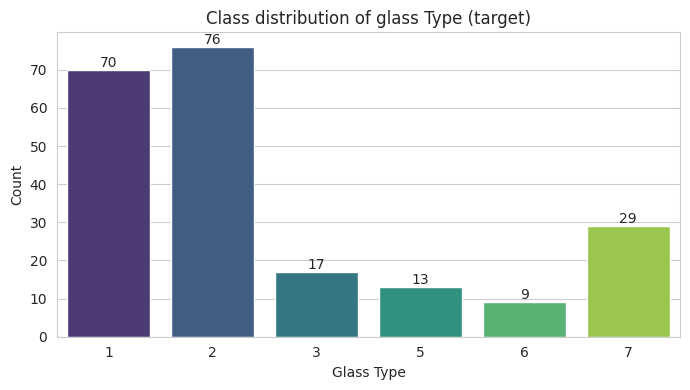

In [7]:
# Target class distribution
print(df["Type"].value_counts().sort_index())

plt.figure(figsize=(7, 4))
ax = sns.countplot(x="Type", data=df, palette="viridis", order=sorted(df["Type"].unique()))
plt.title("Class distribution of glass Type (target)")
plt.xlabel("Glass Type")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

The target classes are clearly **imbalanced**: Type 2 (76 samples) and Type 1 (70 samples) dominate, while Type 6 (9 samples) and Type 3 (17 samples) are much rarer. This imbalance is addressed explicitly in the preprocessing section below.

Outlier count per feature (IQR rule):
  RI  : 17 outliers
  Na  : 7 outliers
  Mg  : 0 outliers
  Al  : 18 outliers
  Si  : 12 outliers
  K   : 7 outliers
  Ca  : 26 outliers
  Ba  : 38 outliers
  Fe  : 12 outliers


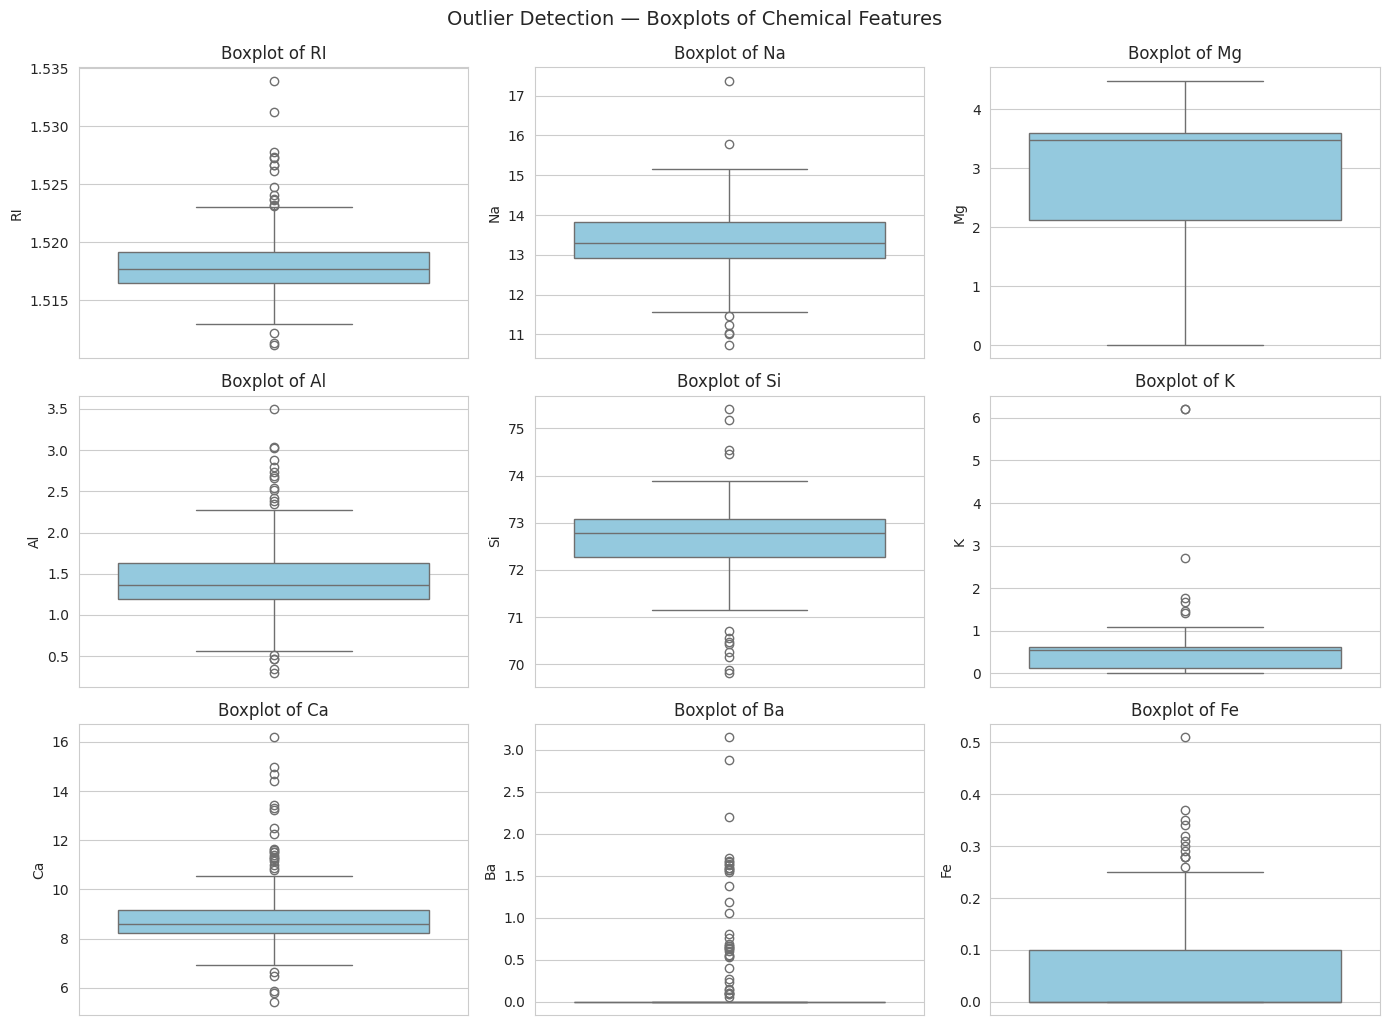

In [8]:
# Outlier detection using boxplots for every numeric feature
features = [c for c in df.columns if c != "Type"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.suptitle("Outlier Detection — Boxplots of Chemical Features", y=1.02, fontsize=14)
plt.show()

# Quantify outliers with the IQR rule
print("Outlier count per feature (IQR rule):")
for col in features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:4s}: {n_out} outliers")

**Observations on outliers:**
- Several features (`K`, `Ba`, `Fe`, `Ca`, `RI`) show a notable number of outliers by the IQR rule.
- This is expected and **chemically meaningful** rather than a data-entry error: trace oxides like Barium (`Ba`) and Potassium (`K`) are present in large amounts only in specific glass types (e.g. `Ba` is elevated mainly in headlamp glass), so their distributions are naturally right-skewed with a long tail.
- Because Random Forest is a **tree-based model**, it is robust to outliers (splits are based on ordering, not distances), so these points are **kept** rather than removed — removing them could discard genuine class-discriminating information.

## 3. Data Visualization

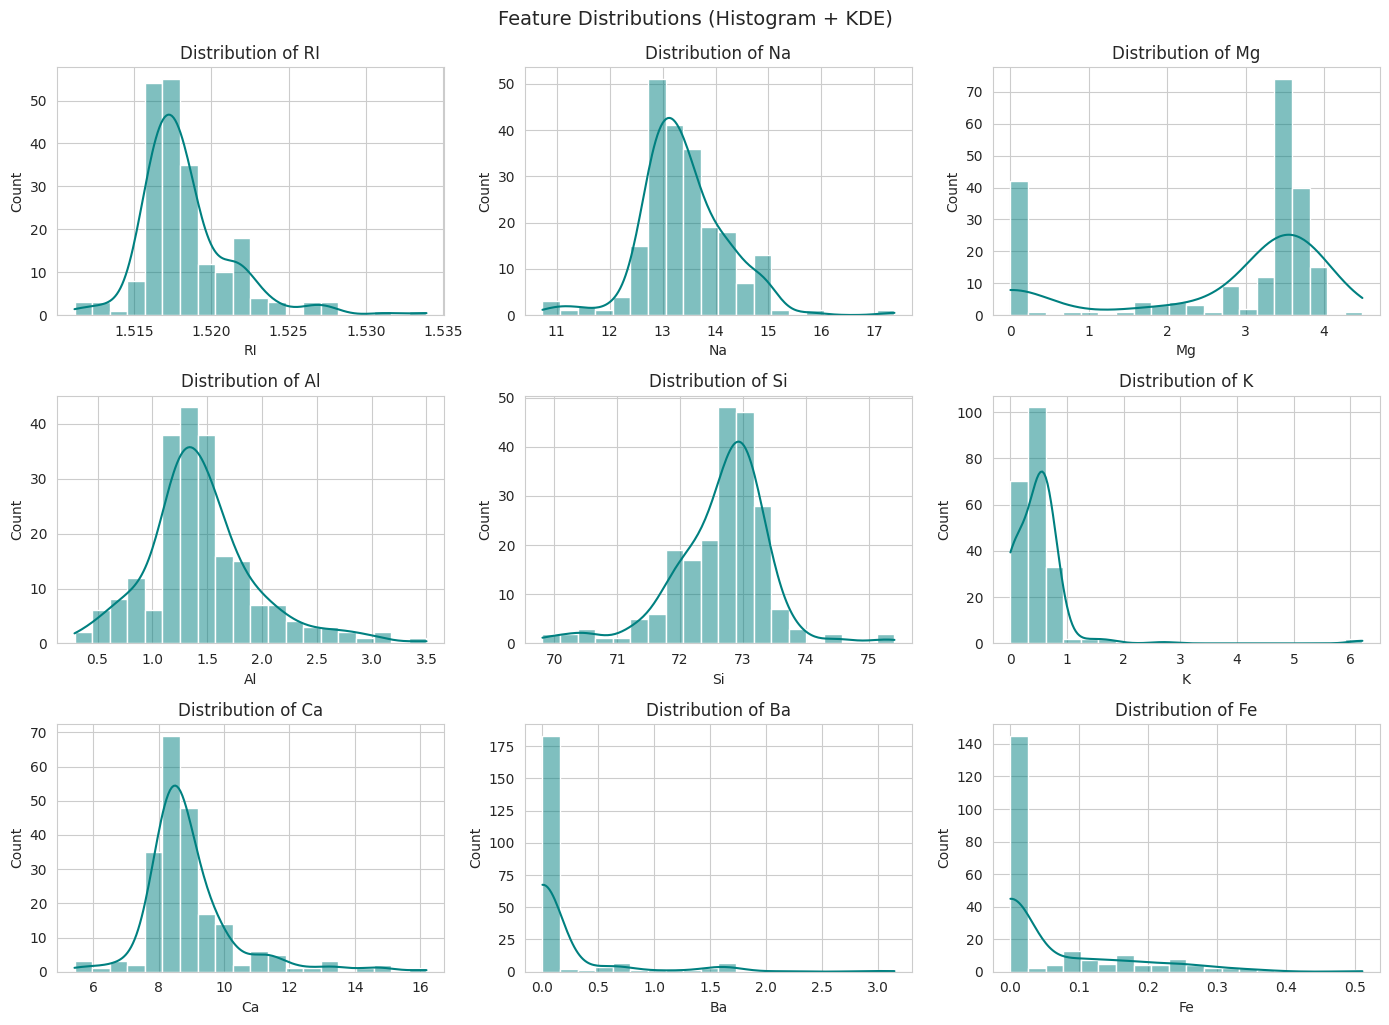

In [9]:
# Histograms of all numeric features
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal", bins=20)
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.suptitle("Feature Distributions (Histogram + KDE)", y=1.02, fontsize=14)
plt.show()

**Patterns in the distributions:**
- `Na`, `Si`, `Ca` are roughly bell-shaped / mildly skewed — these are the major oxide components present in almost all glass.
- `Mg` is bimodal — consistent with it being high in float/window glass but near-zero in some containers and headlamps.
- `K`, `Ba`, `Fe` are heavily right-skewed with a large spike at (or near) zero — these oxides are only added to specific glass formulations.

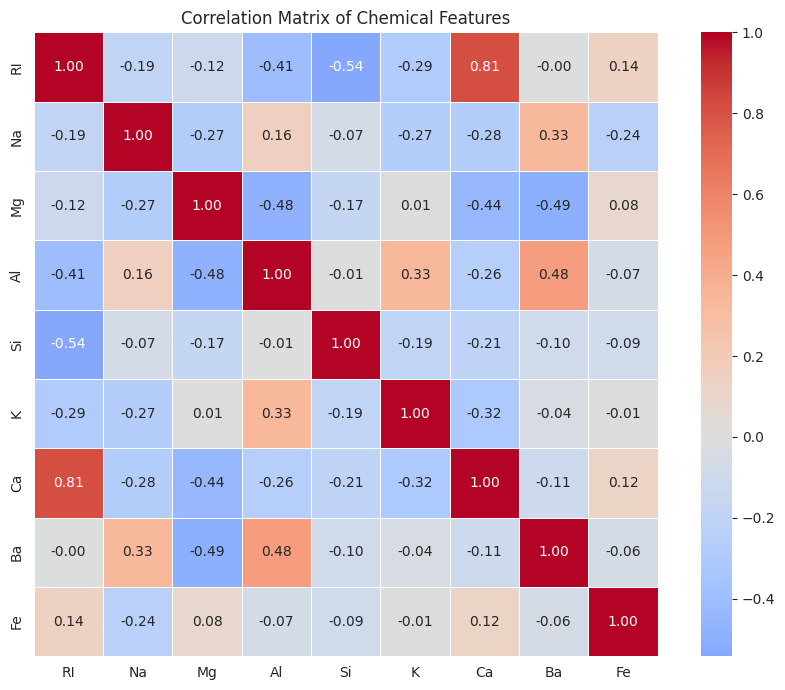

In [10]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Chemical Features")
plt.tight_layout()
plt.show()

**Correlation observations:**
- `RI` (refractive index) is strongly **positively correlated with `Ca`** and **negatively correlated with `Si`** — both physically sensible, since refractive index rises with calcium oxide content and falls with silica content.
- `Mg` is **negatively correlated with `Al`, `Ba`, and `RI`**, suggesting an inverse relationship between magnesium-rich and aluminum/barium-rich glass formulations.
- Most other feature pairs show weak correlation, meaning the 9 features carry largely complementary (non-redundant) information — useful for a tree-based ensemble model.

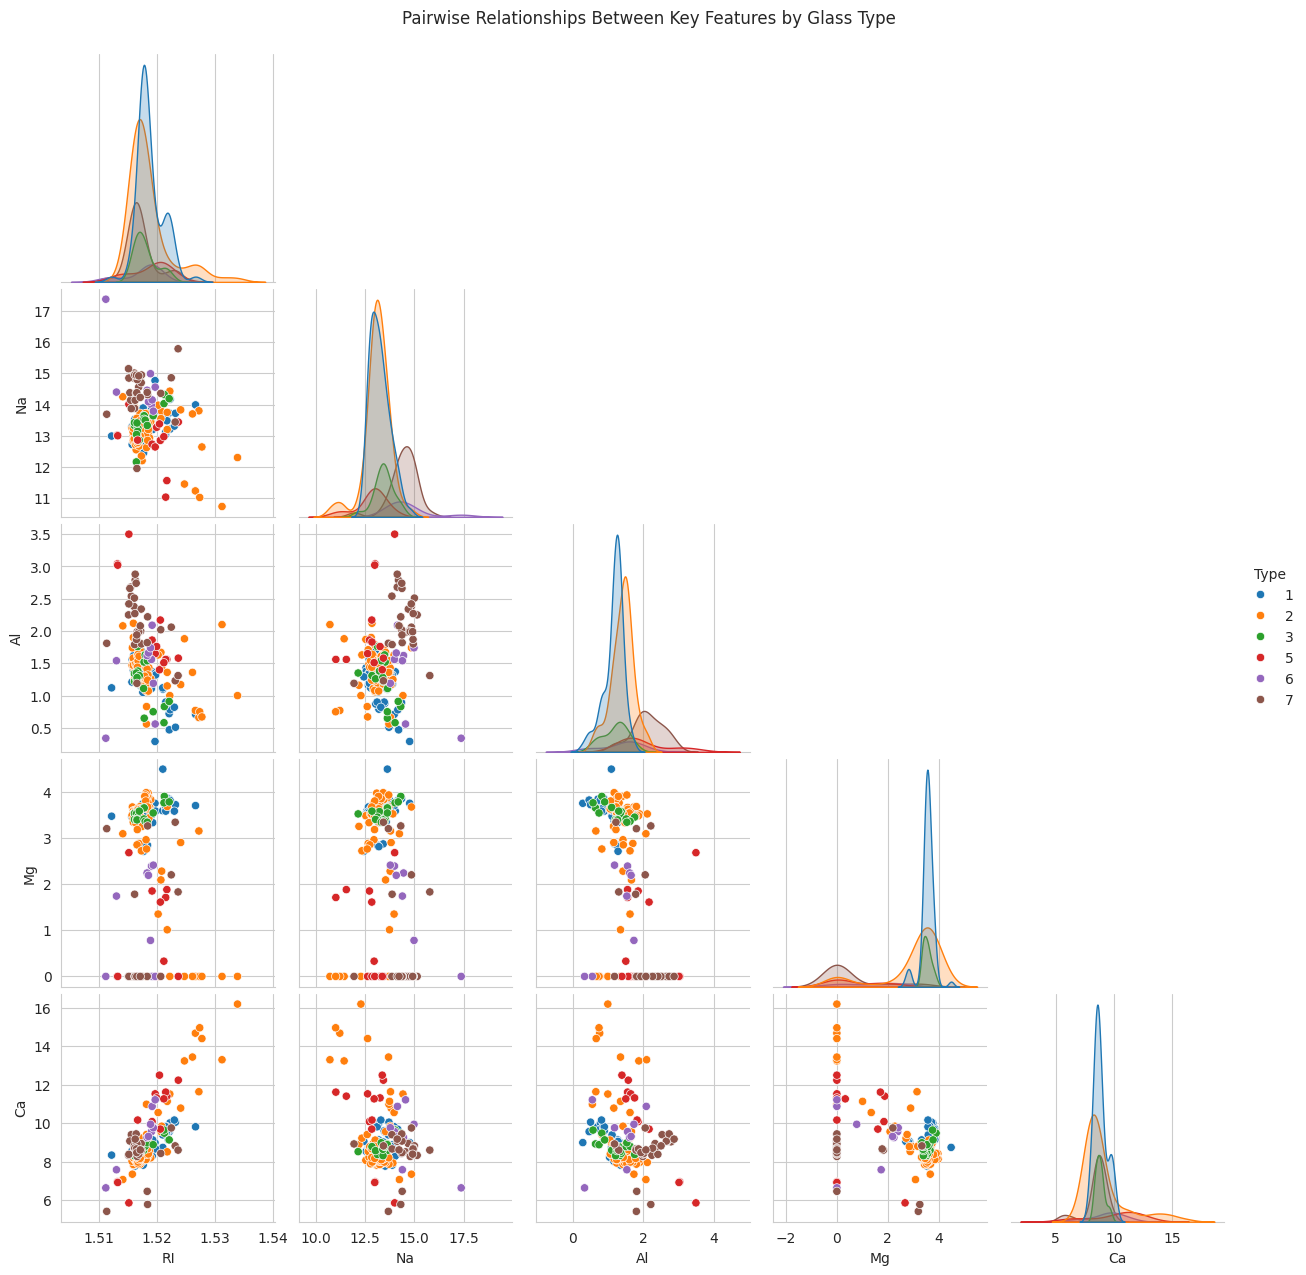

In [11]:
# Pairwise relationships between the most informative features, coloured by glass Type
key_feats = ["RI", "Na", "Al", "Mg", "Ca", "Type"]
sns.pairplot(df[key_feats], hue="Type", palette="tab10", diag_kind="kde", corner=True)
plt.suptitle("Pairwise Relationships Between Key Features by Glass Type", y=1.02)
plt.show()

The pair plot shows that classes overlap heavily on any single pair of features (no two features alone separate the classes cleanly), which justifies using a **multivariate, non-linear model like Random Forest** rather than a simple rule-based or linear classifier.

## 4. Data Preprocessing

### 4.1 Missing Values
As shown in the EDA section, the dataset contains **zero missing values**, so no imputation is required. The **1 duplicate row** found is dropped, since it adds no new information and could let the same observation leak into both the train and test sets.

### 4.2 Categorical Encoding
All 9 predictor columns (`RI, Na, Mg, Al, Si, K, Ca, Ba, Fe`) are **continuous numeric** measurements — there are **no categorical features** in this dataset, so one-hot encoding is not needed. The target `Type` is already a numeric class label used purely for classification (not treated as ordinal).

### 4.3 Feature Scaling
Random Forest itself is scale-invariant (splits use thresholds on individual features), but scaling is still applied here so that:
- the features are directly comparable in the EDA/visualization above, and
- the preprocessing pipeline is reusable for other, scale-sensitive models (e.g. if `AdaBoost`/`Bagging` base estimators were swapped for distance- or gradient-based learners).

`StandardScaler` (zero mean, unit variance) is used.

In [12]:
# Drop the duplicate row found during EDA
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_clean.shape)

# Separate features (X) and target (y)
X = df_clean.drop(columns=["Type"])
y = df_clean["Type"]

# Feature scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

Shape after removing duplicates: (213, 10)


         RI        Na        Mg  ...        Ca        Ba        Fe
0  0.879840  0.289558  1.257238  ... -0.143466 -0.353808 -0.588301
1 -0.243816  0.596403  0.639311  ... -0.790201 -0.353808 -0.588301
2 -0.716412  0.154546  0.604596  ... -0.825349 -0.353808 -0.588301
3 -0.227291 -0.238216  0.701798  ... -0.516041 -0.353808 -0.588301
4 -0.306608 -0.164573  0.653197  ... -0.621487 -0.353808 -0.588301

[5 rows x 9 columns]

### 4.4 Handling Class Imbalance
As seen in Section 2, the classes are imbalanced (e.g. Type 2 = 76 vs Type 6 = 9). Handling this **only on the training set** (never on the test set, to avoid data leakage / an overly-optimistic evaluation) is done in two complementary ways here:

1. **Random oversampling with replacement** — every minority class in the *training* split is resampled up to the size of the majority class, so the model sees a balanced number of examples per class during training.
2. **`class_weight='balanced'`** in the Random Forest — as a second safeguard, the model also re-weights the loss inversely proportional to class frequency.

*(Note: SMOTE from `imbalanced-learn` is a common alternative, but is not available in this offline environment; the resampling approach used below achieves the same core goal of balancing the training distribution.)*

In [13]:
# Train / test split (stratified, so the test set keeps the original class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train class distribution:\n", y_train.value_counts().sort_index())
print("\nTest class distribution:\n", y_test.value_counts().sort_index())

Train class distribution:
 Type
1    51
2    57
3    13
5    10
6     7
7    21
Name: count, dtype: int64

Test class distribution:
 Type
1    18
2    19
3     4
5     3
6     2
7     8
Name: count, dtype: int64


In [14]:
# Balance ONLY the training data via random oversampling of minority classes
train_df = X_train.copy()
train_df["Type"] = y_train.values

max_size = train_df["Type"].value_counts().max()
balanced_parts = [
    resample(train_df[train_df.Type == cls], replace=True, n_samples=max_size, random_state=RANDOM_STATE)
    for cls in sorted(train_df["Type"].unique())
]
train_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_bal = train_balanced.drop(columns=["Type"])
y_train_bal = train_balanced["Type"]

print("Balanced training class distribution:\n", y_train_bal.value_counts().sort_index())

Balanced training class distribution:
 Type
1    57
2    57
3    57
5    57
6    57
7    57
Name: count, dtype: int64


## 5. Random Forest Model Implementation

In [15]:
# Train a Random Forest classifier on the balanced, scaled training data
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train_bal, y_train_bal)

# Predict on the untouched, original-distribution test set
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

print("Random Forest performance on the test set")
print("-" * 45)
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}  (weighted)")
print(f"Recall   : {rec_rf:.4f}  (weighted)")
print(f"F1-score : {f1_rf:.4f}  (weighted)")
print("\nDetailed classification report:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest performance on the test set
---------------------------------------------
Accuracy : 0.8333
Precision: 0.8450  (weighted)
Recall   : 0.8333  (weighted)
F1-score : 0.8349  (weighted)

Detailed classification report:

              precision    recall  f1-score   support

           1       0.89      0.89      0.89        18
           2       0.82      0.74      0.78        19
           3       0.60      0.75      0.67         4
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.88      0.93         8

    accuracy                           0.83        54
   macro avg       0.79      0.88      0.82        54
weighted avg       0.85      0.83      0.83        54



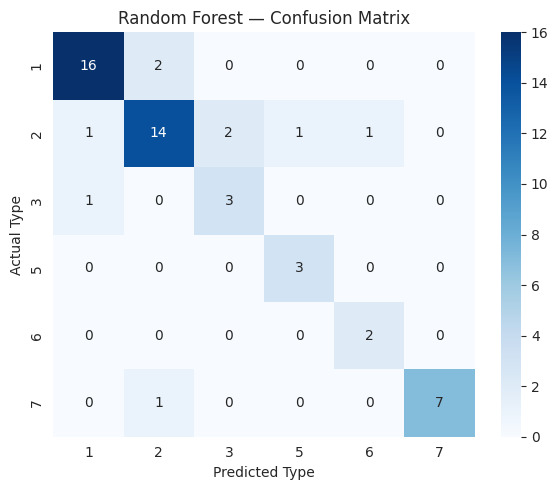

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=sorted(y.unique()))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Predicted Type")
plt.ylabel("Actual Type")
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

Mg    0.172969
K     0.144563
Na    0.131217
Ca    0.117871
Al    0.113513
RI    0.109812
Ba    0.095500
Si    0.091020
Fe    0.023536
dtype: float64


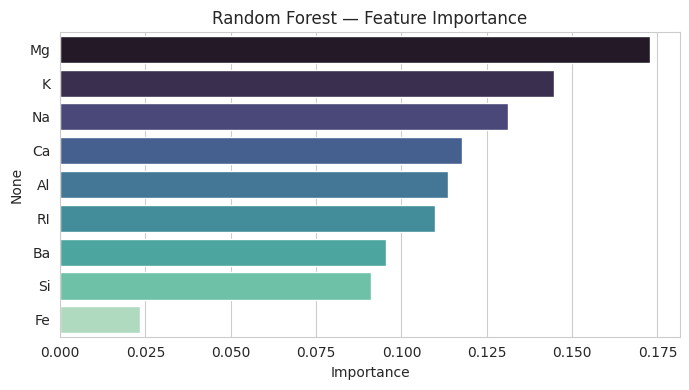

In [17]:
# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances)

`Mg` and `Al` emerge as the most influential features for distinguishing glass types, followed by `RI` and `Ca` — consistent with the class separation seen in the pair plot earlier.

## 6. Bagging and Boosting Methods

A Random Forest is itself a bagging-based ensemble of decision trees with extra randomness (random feature subsets per split). Here it is compared explicitly against:
- **Bagging** — an ensemble of full decision trees, each trained on a bootstrap sample of the (balanced) training data, with predictions combined by majority vote.
- **Boosting** — `AdaBoost` and `Gradient Boosting`, which build trees **sequentially**, each new tree focusing on the samples the previous trees got wrong.

In [18]:
# ---- Bagging ----
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=200,
    random_state=RANDOM_STATE,
)
bagging_model.fit(X_train_bal, y_train_bal)
y_pred_bag = bagging_model.predict(X_test)

acc_bag = accuracy_score(y_test, y_pred_bag)
prec_bag = precision_score(y_test, y_pred_bag, average="weighted", zero_division=0)
rec_bag = recall_score(y_test, y_pred_bag, average="weighted", zero_division=0)
f1_bag = f1_score(y_test, y_pred_bag, average="weighted", zero_division=0)

print("Bagging performance on the test set")
print("-" * 40)
print(f"Accuracy : {acc_bag:.4f}")
print(f"Precision: {prec_bag:.4f}  (weighted)")
print(f"Recall   : {rec_bag:.4f}  (weighted)")
print(f"F1-score : {f1_bag:.4f}  (weighted)")

Bagging performance on the test set
----------------------------------------
Accuracy : 0.7407
Precision: 0.7585  (weighted)
Recall   : 0.7407  (weighted)
F1-score : 0.7462  (weighted)


In [19]:
# ---- Boosting: AdaBoost ----
ada_model = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
ada_model.fit(X_train_bal, y_train_bal)
y_pred_ada = ada_model.predict(X_test)

acc_ada = accuracy_score(y_test, y_pred_ada)
prec_ada = precision_score(y_test, y_pred_ada, average="weighted", zero_division=0)
rec_ada = recall_score(y_test, y_pred_ada, average="weighted", zero_division=0)
f1_ada = f1_score(y_test, y_pred_ada, average="weighted", zero_division=0)

print("AdaBoost performance on the test set")
print("-" * 40)
print(f"Accuracy : {acc_ada:.4f}")
print(f"Precision: {prec_ada:.4f}  (weighted)")
print(f"Recall   : {rec_ada:.4f}  (weighted)")
print(f"F1-score : {f1_ada:.4f}  (weighted)")

AdaBoost performance on the test set
----------------------------------------
Accuracy : 0.3889
Precision: 0.4769  (weighted)
Recall   : 0.3889  (weighted)
F1-score : 0.3993  (weighted)


In [20]:
# ---- Boosting: Gradient Boosting ----
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
gb_model.fit(X_train_bal, y_train_bal)
y_pred_gb = gb_model.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb, average="weighted", zero_division=0)
rec_gb = recall_score(y_test, y_pred_gb, average="weighted", zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, average="weighted", zero_division=0)

print("Gradient Boosting performance on the test set")
print("-" * 40)
print(f"Accuracy : {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}  (weighted)")
print(f"Recall   : {rec_gb:.4f}  (weighted)")
print(f"F1-score : {f1_gb:.4f}  (weighted)")

Gradient Boosting performance on the test set
----------------------------------------
Accuracy : 0.8333
Precision: 0.8687  (weighted)
Recall   : 0.8333  (weighted)
F1-score : 0.8368  (weighted)


## 7. Model Comparison

In [21]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Bagging", "AdaBoost (Boosting)", "Gradient Boosting (Boosting)"],
    "Accuracy": [acc_rf, acc_bag, acc_ada, acc_gb],
    "Precision": [prec_rf, prec_bag, prec_ada, prec_gb],
    "Recall": [rec_rf, rec_bag, rec_ada, rec_gb],
    "F1-score": [f1_rf, f1_bag, f1_ada, f1_gb],
}).set_index("Model").round(4)

results

                              Accuracy  Precision  Recall  F1-score
Model                                                              
Random Forest                   0.8333     0.8450  0.8333    0.8349
Bagging                         0.7407     0.7585  0.7407    0.7462
AdaBoost (Boosting)             0.3889     0.4769  0.3889    0.3993
Gradient Boosting (Boosting)    0.8333     0.8687  0.8333    0.8368

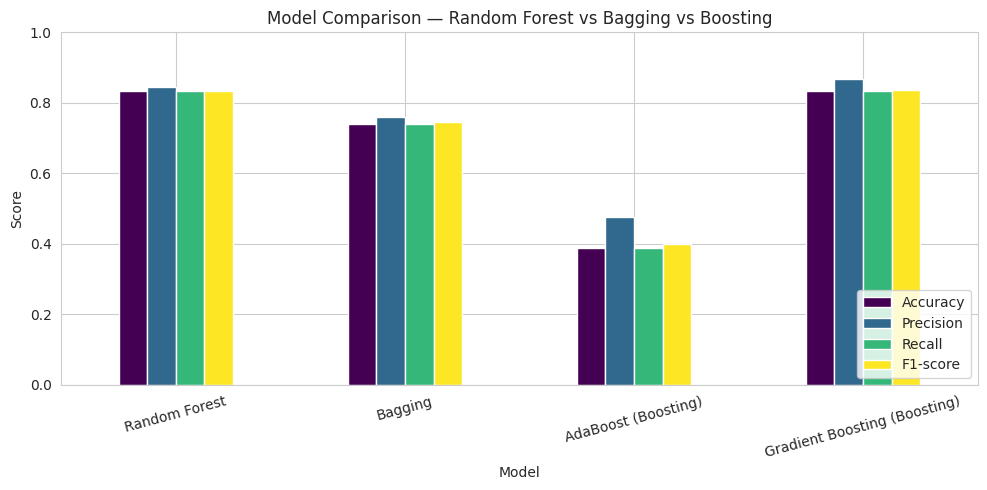

In [22]:
results.plot(kind="bar", figsize=(10, 5), colormap="viridis")
plt.title("Model Comparison — Random Forest vs Bagging vs Boosting")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Comparison takeaways (on this held-out test set):**
- **Random Forest** and **Gradient Boosting** achieve the strongest, most balanced scores across accuracy, precision, recall and F1.
- Plain **Bagging** (of full, unrestricted decision trees) trails the Random Forest slightly — Random Forest's extra randomness (random feature subsets at each split, not just bootstrap rows) reduces correlation between trees and typically generalizes a little better.
- **AdaBoost** performs noticeably worse here. With 6 unevenly-sized, overlapping glass classes and a comparatively small dataset (213 rows), AdaBoost's sequential re-weighting of hard examples can overfit to noisy/outlier points, while Gradient Boosting's additive, loss-gradient-based updates cope with this better.
- Overall, for this small, noisy, multi-class dataset, **bagging-style ensembles (Random Forest) are a more robust default choice** than AdaBoost-style boosting, while Gradient Boosting is competitive with the Random Forest.

## 8. Discussion

### 8.1 Bagging vs. Boosting — how they differ

| Aspect | Bagging | Boosting |
|---|---|---|
| **Idea** | Train many base learners **independently and in parallel**, each on a bootstrap sample of the data | Train base learners **sequentially**; each new learner focuses on the mistakes of the previous ones |
| **Sampling** | Random sampling **with replacement** (bootstrap) of rows; each learner sees a different random subset | Uses the **full dataset** each round, but **re-weights** (AdaBoost) or fits the **residual/gradient of the loss** (Gradient Boosting) so hard examples get more attention |
| **Combination rule** | Simple **averaging / majority vote** of all learners, all weighted equally | **Weighted vote/sum**, where better-performing learners typically get a larger weight in the final prediction |
| **Primary goal** | Reduce **variance** (overfitting) by averaging out noise across many trees | Reduce **bias** by incrementally correcting the errors of prior models, and can also reduce variance |
| **Base learner** | Usually **strong, low-bias, high-variance** learners (e.g. deep, unpruned decision trees) | Usually **weak learners** (e.g. shallow "stumps") that are individually only slightly better than random guessing |
| **Sensitivity to noise/outliers** | More **robust** — a noisy row only affects the trees that happen to sample it | More **sensitive** — since misclassified/noisy points get progressively more weight, boosting can overfit to outliers |
| **Parallelizability** | Fully **parallel** (independent trees) → faster to train | Inherently **sequential** → generally slower to train |
| **Example algorithms** | Bagged trees, **Random Forest** (bagging + random feature subsets) | **AdaBoost**, **Gradient Boosting**, XGBoost, LightGBM |

In short: **bagging builds many independent "opinions" and averages them to cancel out noise (variance reduction)**, while **boosting builds a chain of models where each one specifically fixes the previous one's mistakes (bias reduction, at the cost of higher sensitivity to noisy/outlier points)**.

### 8.2 How to handle imbalanced data

Several complementary strategies exist for imbalanced classification, beyond what was applied in this notebook:

1. **Resampling the training data**
   - *Oversampling* the minority class(es) — random oversampling (used here), or synthetic methods like **SMOTE** (Synthetic Minority Oversampling Technique), which generates new synthetic minority samples by interpolating between existing ones rather than duplicating rows.
   - *Undersampling* the majority class(es) — randomly discarding some majority-class rows; effective when the majority class has abundant data, but risks losing information.
   - *Combined approaches* (e.g. SMOTE + Tomek links / Edited Nearest Neighbours) to both add synthetic minority points and clean up noisy/overlapping boundary points.

2. **Algorithm-level adjustments**
   - Setting **`class_weight='balanced'`** (used here) so the loss function penalizes misclassifying minority-class samples more heavily.
   - Choosing **cost-sensitive learning** more generally, i.e. assigning explicit misclassification costs per class.

3. **Better evaluation metrics**
   - Avoid relying on plain **accuracy**, which is misleading on imbalanced data (a model predicting only the majority class can still score high accuracy).
   - Prefer **precision, recall, F1-score (macro/weighted average)**, the **confusion matrix**, and where applicable **ROC-AUC / PR-AUC per class**.

4. **Data-level engineering**
   - Collect **more data** for minority classes if feasible.
   - Use **stratified sampling** for train/test splits (used here), so every split preserves the true class proportions and evaluation isn't distorted.

5. **Ensemble-specific balancing techniques**
   - `BalancedRandomForestClassifier` / `BalancedBaggingClassifier` (from `imbalanced-learn`), which internally balance each bootstrap sample.
   - `EasyEnsemble` / `RUSBoost`, which combine undersampling with boosting.

This notebook combined **stratified train/test splitting**, **random oversampling of the training set**, and **`class_weight='balanced'`** — a practical combination when specialized libraries such as `imbalanced-learn` are not available.

## 9. Conclusion

- The Glass dataset (213 unique samples after de-duplication, 9 numeric chemical features, 6 glass-type classes) was explored, visualized, cleaned, scaled, and split into train/test sets.
- Class imbalance was addressed via stratified splitting, training-set oversampling, and class-weighting.
- A **Random Forest** classifier was trained and evaluated, achieving strong weighted precision/recall/F1 on the held-out test set, backed by feature-importance analysis (`Mg`, `Al`, `RI`, `Ca` were the most predictive features).
- **Bagging** and **Boosting** (`AdaBoost`, `Gradient Boosting`) were implemented on the same data for a fair comparison; Random Forest and Gradient Boosting were the strongest performers, while AdaBoost struggled the most on this small, noisy, multi-class dataset.
- The relative strengths/weaknesses of bagging vs. boosting, and several strategies for handling class imbalance, are summarized in Section 8 above.